# ML Algorithm classifiers for rough analysis of regret

最关键的判断标准

重新定义 target 后，可能出现三种结果：

分类 AUC 高、回归 R² 低
Distance 可以作为 failure alarm，但不能精确估计 slowdown 大小。这完全可以形成一个可靠结论。
分类 AUC 和回归 R² 都高
Distance 既能检测 failure，也能估计严重程度，是最理想结果。
分类 AUC 接近 0.5，回归 R² 接近 0
MMD、KS、WS 无法单独判断 BAO failure，需要加入 Query 结构、baseline latency、cardinality、plan features 等信息。

## Import and Random seed

In [43]:
import os
import joblib
import random
import numpy as np
import pandas as pd
from torch.ao.nn.quantized.functional import threshold

In [44]:
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    # torch.manual_seed(seed)

    # if torch.cuda.is_available():
    #     torch.cuda.manual_seed_all(seed)


set_seed(SEED)

## 2. Data Load

In [45]:
# Read data from a CSV file into a pandas DataFrame
regret_df = pd.read_pickle("dataset/tpc-ds/precessed_regret_queries_100_add9scores_scaled.pkl")

In [46]:
total_lat = (regret_df['bao_latency'] - regret_df['optimal_latency']).sum()
print(total_lat)

6425237.772


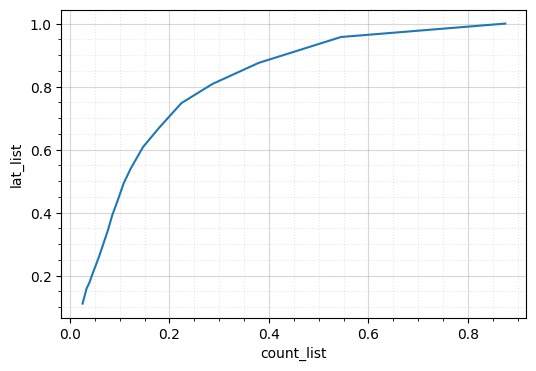

In [47]:
count_list = []
lat_list = []
for i in np.arange(0, 2, 0.1):
    filtered = df[df['reg_log'] > i]
    result = (filtered['bao_latency'] - filtered['optimal_latency']).sum()
    count = (df["reg_log"] > i).sum()
    # print(f"{i:.2f}", count, f"{count/8201:.3f}", f"{result:.0f}", f"{result/total_lat:.3f}")
    count_list.append(count / 8201)
    lat_list.append(result / total_lat)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(count_list, lat_list)
plt.xlabel('count_list')
plt.ylabel('lat_list')
plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', alpha=0.3)
plt.show()

In [48]:
count = (regret_df["bao_latency"] > regret_df["default_latency"]).sum()
print(count)
stats = regret_df["reg_log"].describe()
print(stats)

2308
count    8101.000000
mean        0.322650
std         0.532931
min         0.000000
25%         0.034762
50%         0.124939
75%         0.362196
max         5.386176
Name: reg_log, dtype: float64


In [49]:
def generate_regret_classifier_dataset(df, threshold=1.0, psql_default=False):
    feature_columns = ["query_id", "mmd_score", "ks_stat", "ks_log_pvalue", "ws_score",
                       "mmd", "energy_distance", "wasserstein", "ks", "js_divergence", "js_distance", "kl_x_to_y",
                       "kl_y_to_x", "symmetric_kl"]
    # dataset["ks_log_pvalue"] = -np.log10(dataset["ks_pvalue"].clip(lower=1e-300))
    # dataset["reg_log"] = np.log10(dataset["regret"].clip(lower=1e-300))
    if psql_default:
        df["target"] = np.where((df["bao_latency"] > df["default_latency"]), 1, 0)
    else:
        df["target"] = np.where((df["reg_log"] > threshold), 1, 0)

    X = df[feature_columns]
    y = df["target"]
    return X, y

In [50]:
X, y = generate_regret_classifier_dataset(regret_df, threshold=1.1)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8101, 14)
y shape: (8101,)


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


def train_classifiers(X_train, X_test, y_train, y_test, threshold, res_path,
                      model_path="models/classifier_best_model.pkl"):
    # =========================================================
    # 4. 定义多个分类算法
    # =========================================================
    models = {

        # "Logistic Regression": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("smote", SMOTE(random_state=42)),
        #     ("model", LogisticRegression(max_iter=1000, random_state=42)),
        # ]),

        # "KNN": Pipeline([
        #     ("scaler", StandardScaler()),
        #     ("smote", SMOTE(random_state=42)),
        #     ("model", KNeighborsClassifier())
        # ]),

        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("smote", SMOTE(random_state=42)),
            ("model", SVC(
                probability=True,
                random_state=42
            ))
        ]),

        # "Decision Tree": Pipeline([
        #     ("smote", SMOTE(random_state=42)),
        #     ("model", DecisionTreeClassifier(random_state=42))
        # ]),

        "Random Forest": Pipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", RandomForestClassifier(
                random_state=42
            ))
        ]),

        "Gradient Boosting": Pipeline([
            ("smote", SMOTE(random_state=42)),
            ("model", GradientBoostingClassifier(
                random_state=42
            ))
        ])
    }

    # =========================================================
    # 5. 训练并比较模型
    # =========================================================

    results = []
    trained_models = {}

    for model_name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        # 大部分模型都支持 predict_proba
        if hasattr(model, "predict_proba"):
            y_probability = model.predict_proba(X_test)[:, 1]
        else:
            y_probability = None

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )
        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )
        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        if y_probability is not None and y_test.nunique() == 2:
            roc_auc = roc_auc_score(y_test, y_probability)
        else:
            roc_auc = None

        results.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC_AUC": roc_auc
        })

        trained_models[model_name] = model

    # =========================================================
    # 6. 显示比较结果
    # =========================================================

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="F1",
        ascending=False
    ).reset_index(drop=True)
    # =========================================================
    # 5. 获取最佳模型
    # =========================================================

    best_model_name = results_df.loc[
        0,
        "Model"
    ]

    best_model = trained_models[
        best_model_name
    ]

    best_predictions = best_model.predict(
        X_test
    )

    # =========================================================
    # 6. 获取最佳模型的 Metrics
    # =========================================================

    best_metrics = {
        "Accuracy": results_df.loc[0, "Accuracy"],
        "Precision": results_df.loc[0, "Precision"],
        "Recall": results_df.loc[0, "Recall"],
        "F1": results_df.loc[0, "F1"],
        "ROC_AUC": results_df.loc[0, "ROC_AUC"]
    }

    # =========================================================
    # 7. 保存模型 Package
    # =========================================================

    # 如果 model_path 包含目录，则自动创建
    model_dir = os.path.dirname(model_path)

    if model_dir:
        os.makedirs(
            model_dir,
            exist_ok=True
        )

    model_package = {
        # 完整 Pipeline
        "model": best_model,
        # 最佳模型名称
        "model_name": best_model_name,
        # 训练时的 Feature 名称和顺序
        "feature_names": list(X.columns),
        # 最佳模型评价指标
        "metrics": best_metrics
    }

    joblib.dump(model_package,model_path)

    # =========================================================
    # 8. 保存模型比较结果
    # =========================================================

    with open(res_path, "a", encoding="utf-8") as file:
        file.write("\n\n========================================\n")
        file.write(f"Model Comparison:thresthold = {threshold}\n")
        file.write("========================================\n")

        file.write(
            results_df.round(4).to_string(
                index=False
            )
        )

        # -----------------------------------------------------
        # 最佳模型
        # -----------------------------------------------------
        file.write( "\n\nBest Model:\n")
        file.write( best_model_name)

        # -----------------------------------------------------
        # 最佳模型 Metrics
        # -----------------------------------------------------
        file.write("\n\nBest Model Metrics:\n")

        for metric_name, value in best_metrics.items():
            if value is not None:
                file.write(
                    f"{metric_name}: {value:.4f}\n"
                )
            else:
                file.write(
                    f"{metric_name}: None\n"
                )

        # -----------------------------------------------------
        # Confusion Matrix
        # -----------------------------------------------------

        file.write(
            "\nConfusion Matrix:\n"
        )
        file.write(
            str(
                confusion_matrix(
                    y_test,
                    best_predictions
                )
            )
        )

        # -----------------------------------------------------
        # Classification Report
        # -----------------------------------------------------

        file.write(
            "\n\nClassification Report:\n"
        )
        file.write(
            classification_report(
                y_test,
                best_predictions,
                digits=4,
                zero_division=0
            )
        )

        # -----------------------------------------------------
        # 保存模型路径
        # -----------------------------------------------------
        file.write(
            f"\nSaved Model Path:\n{model_path}\n"
        )

    # =========================================================
    # 9. Console 输出
    # =========================================================

    print("\n========================================")
    print("Model Training Completed")
    print("========================================")

    print(
        results_df.round(4).to_string(
            index=False
        )
    )

    print("\nBest Model:")
    print(best_model_name)

    print("\nBest Model Metrics:")

    for metric_name, value in best_metrics.items():
        if value is not None:
            print(
                f"{metric_name}: {value:.4f}"
            )

    print(
        f"\nBest model saved to: {model_path}"
    )

    # =========================================================
    # 10. 返回结果
    # =========================================================

    return best_model, results_df

In [54]:
# thresholds = np.linspace(0.5,1.5, 11) # 0.36 equals to 75% percentile
thresholds = [1.1]
for t in thresholds:
    X, y = generate_regret_classifier_dataset(regret_df, threshold=t, psql_default=False)
    X_train, X_test, y_train, y_test = train_test_split(X,y,
        test_size=0.4,random_state=42,stratify=y)
    X_test.to_pickle("dataset/tpc-ds/data_X_test_t1.1_test0.4.pkl")
    y_test.to_pickle("dataset/tpc-ds/data_y_test_t1.1_test0.4.pkl")

    X_train = X_train.drop(columns=["query_id"])
    X_test = X_test.drop(columns=["query_id"])
    train_classifiers(X_train, X_test, y_train, y_test, t,"results/testing.txt")


Model Training Completed
            Model  Accuracy  Precision  Recall     F1  ROC_AUC
              SVM    0.5890     0.1284   0.748 0.2192   0.7113
Gradient Boosting    0.6294     0.1271   0.648 0.2125   0.7139
    Random Forest    0.8115     0.1454   0.296 0.1950   0.7013

Best Model:
SVM

Best Model Metrics:
Accuracy: 0.5890
Precision: 0.1284
Recall: 0.7480
F1: 0.2192
ROC_AUC: 0.7113

Best model saved to: models/classifier_best_model.pkl
